# Mission Design and Trajectory Analysis
These are some notes from a [lecture](youtube.com/watch?v=9wVUUeN04Rk) by Helge Eichhorn

### What is Space Mission Design?
- Determining how a spacecraft will reach its target orbit (efficient, reasonable amount of time and not break the laws of physics)

In [21]:
%matplotlib inline
import plyades as pl
import plyades.bodies as bd
import numpy as np
from scipy import optimize
from IPython.display import Image
from astropy.time import Time
import astropy.units as units
from bokeh.io import output_notebook
output_notebook()

Loading BokehJS ...

## Definition of State Vectors
- $\overrightarrow{r}$ $ \in $ $R^{3}$: Position vector
- $\overrightarrow{v}$ $ \in $ $R^{3}$: Velocity vector
- $t$: Epoch e.g. in Julian days
- Cooridnate frame
- Central body (e.g. gravitational parameter $\mu = GM$)

In [25]:
# Position and velocity vectors with AstroPy units
iss_r = np.array([
    -2775.03475,
    4524.24941,
    4207.43331,
    ]) * units.km
iss_v = np.array([
    -3.641793088,
    -5.665088604,
    3.67950067,
    ]) * units.km/units.s
# Time class from AstroPy
iss_t = Time('2015-08-28T12:00:00.000')
# Reference frame is Earth-Centered Intertial (ECI)
frame = 'ECI'
# Central body is Earth
body = bd.EARTH

iss = pl.State(iss_r, iss_v, iss_t, frame, body)
iss

UnitConversionError: 'km / s' (speed) and 'km' (length) are not convertible

### Determination of Keplerian Orbital Elements
- Shape of the orbital ellipse (or other conic section):
    - $a$: Semi-major axis
    - $e$: Eccentricity
- Orientation of the orbital plane:
    - $i$: inclination
    - $\Omega$: Longitude of the ascending node
- Orientation of the orbital ellipse within the orbital plane
    - $\omega$: Argument of periapsis
- Position of the orbiting body on the orbital ellipse at a given point:
    - $v$: True anomaly

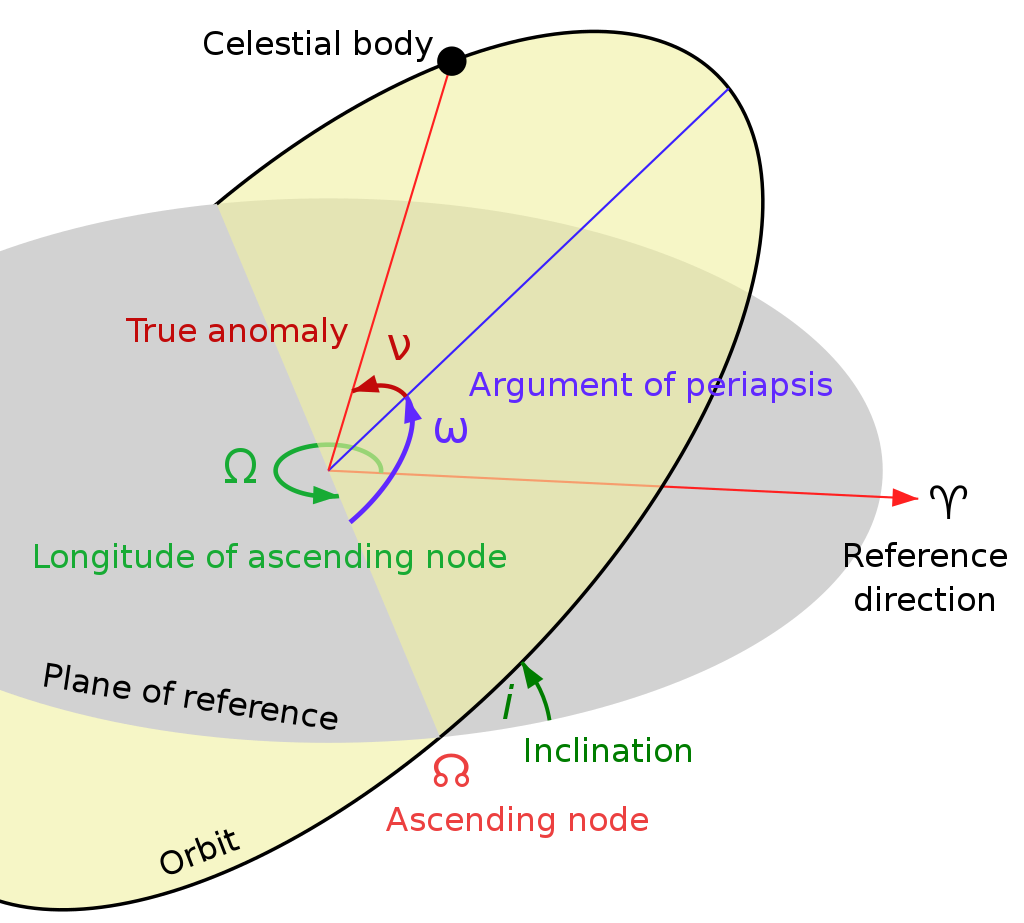

In [24]:
Image('orbital_elements.png',width=300)

### Inputs
- $\overrightarrow{r}$
- $\overrightarrow{v}$
- $\mu$

### Solving Kepler's Equation

Paraphrasing Kepler's Second Law:
- The radius vector sweeps equal areas in equal fractions of time

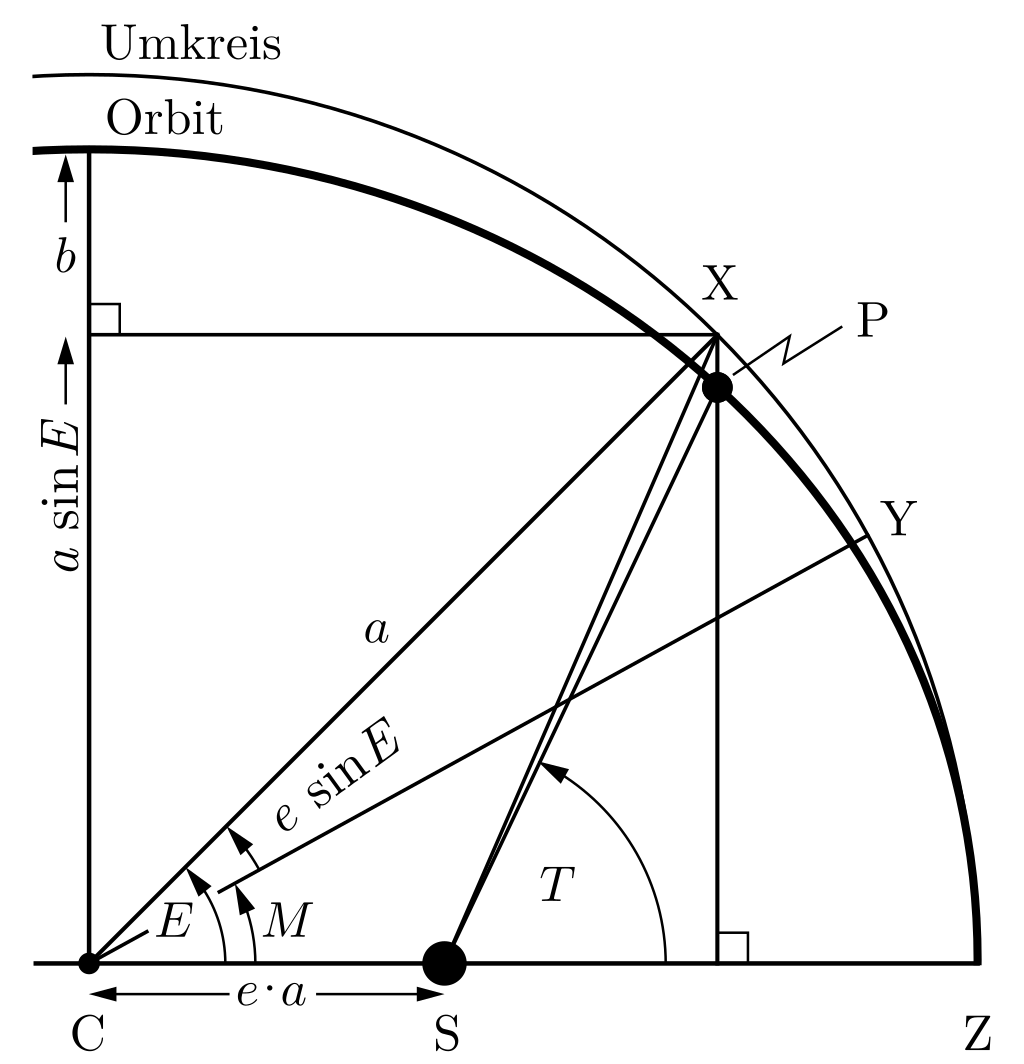

In [27]:
Image('keplers_equation.png', width= 300)
#Umkreis = Circumcircle

- $M$: Mean anomaly - angle at the center sweeping the circumcircle of the orbit
- $E$: Eccentric anomaly - angle at the center sweeping the orbital ellipse
- $v$: True anomaly - angle at the focus sweeping the orbit ellipse